# ST Perturbation Model — Scaling Evaluation

Systematic evaluation of State Transition (ST) model performance across latent sizes.

**Layout:**
- Scaling lines (AE, VAE, PCA) across latent dims 10→2048
- Foundation model dots (SE, scGPT, scConcept, scimilarity) at their native dim
- Confidence bands from 5 seeds
- dw=0.0 (pure latent) vs dw=0.1 (gene-space loss) comparison
- Per-cell-type breakdown for key metrics

In [1]:
import os
import re
import glob
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import anndata as ad
import scanpy as sc
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({"font.size": 11, "axes.titlesize": 12})

SCALING_DISPLAY = {"AE": "AE", "PCA": "PCA", "nlscVI": "VAE"}

## 1. Config

In [2]:
CKPT = "best"  # "best" or "last"

SCALING_MODELS = {
    "AE":    [10, 32, 128, 512, 2048],
    "nlscVI": [10, 32, 128, 512, 2048],
    "PCA":   [10, 32, 128, 512, 2048],
}

FM_MODELS = {
    "SE":          2058,
    "scGPT":       512,
    "scConcept":   512,
    "scimilarity": 128,
}

DW_VALUES = ["0.0", "0.1"]

SCALING_COLORS = {"AE": "#2171b5", "nlscVI": "#ae017e", "PCA": "#ffbf00"}
SCALING_MARKERS = {"AE": "o", "nlscVI": "s", "PCA": "D"}
FM_COLORS = {"SE": "#2ca02c", "scGPT": "#d62728", "scConcept": "#9467bd", "scimilarity": "#8c564b"}
FM_MARKERS = {"SE": "*", "scGPT": "P", "scConcept": "X", "scimilarity": "^"}
FM_DISPLAY = {"SE": "SE", "scGPT": "scGPT", "scConcept": "scConcept", "scimilarity": "SCimilarity"}
DW_LINESTYLES = {"0.0": "-", "0.1": "--"}
DW_COLORS = {"0.0": "#1b9e77", "0.1": "#d95f02"}

## 2. Data Loading

In [3]:
METRICS = [
    ("distributional", "r2_score", None, "$R^2$", True),
    ("distributional", "mse", None, "MSE", False),
    ("distributional", "energy_distance", None, "Energy distance", False),
    ("distributional", "mmd_rbf", None, "MMD-RBF", False),
    ("distributional", "pearson_delta", None, "Pearson delta", True),
    ("distributional", "knn_purity_10", None, "KNN purity (k=10)", True),
    ("distributional", "knn_purity_norm", None, "KNN purity (normalized)", True),
    ("pathway", "average", "spearman", "Pathway Spearman", True),
    ("coexpression", "average", "spearman", "Coexpression Spearman", True),
    ("cellcycle", "proportion_same_phase", None, "Cell-cycle (same phase)", True),
    ("deg", "pred_deg_dice_100", "wilcoxon", "DEG dice@100 (pred)", True),
    ("deg", "pred_mean_genediff_spearman", "wilcoxon", "Mean gene-diff Spearman", True),
    ("cytokine", "average", "spearman", "Cytokine Spearman", True),
]

df_all = pd.read_csv("../frozen/figs/decoder_only_st.csv")
df_all["dw"] = df_all.dw.astype(str)

## 3. Aggregate Rank Scores

Rank-based aggregation: for each metric, rank all (model, latent) entries 1–N, then average ranks within category.
- **Statistical**: $R^2$, Energy distance
- **Biological**: Cell-cycle, DEG dice@100, Mean gene-diff Spearman, Coexpression Spearman, Pathway Spearman
- **Perturbational**: KNN purity (normalized)

Lower rank = better.

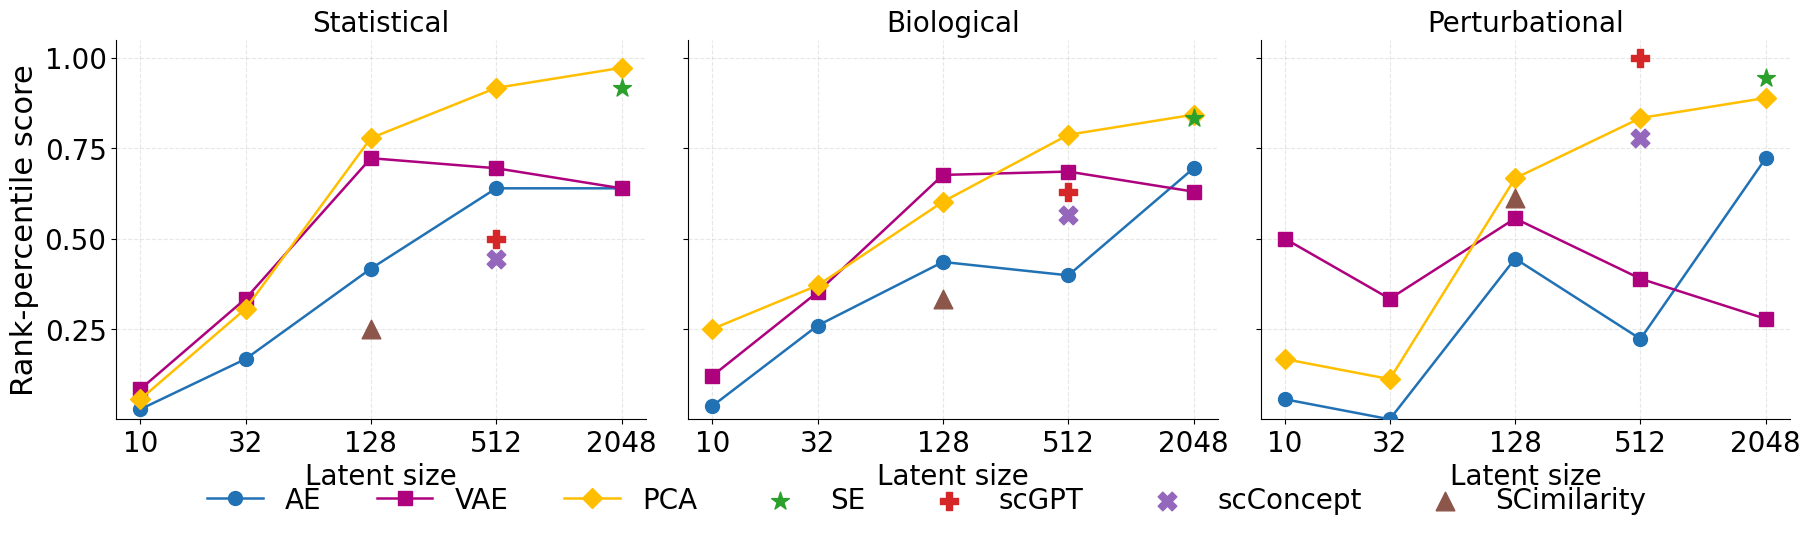


Aggregate scores (higher = better):


,,category,Biological,Perturbational,Statistical,Overall
model,latent,is_fm,,,,
PCA,2048,False,0.8,0.9,1.0,0.9
SE,2058,True,0.8,0.9,0.9,0.9
PCA,512,False,0.8,0.8,0.9,0.8
scGPT,512,True,0.6,1.0,0.5,0.7
AE,2048,False,0.7,0.7,0.6,0.7
PCA,128,False,0.6,0.7,0.8,0.7
nlscVI,128,False,0.7,0.6,0.7,0.7
scConcept,512,True,0.6,0.8,0.4,0.6
nlscVI,512,False,0.7,0.4,0.7,0.6


In [4]:
RANK_CATEGORIES = {
    "Statistical": {
        "$R^2$": True,
        "Energy distance": False,
    },
    "Biological": {
        "Cell-cycle (same phase)": True,
        "DEG dice@100 (pred)": True,
        "Mean gene-diff Spearman": True,
        "Coexpression Spearman": True,
        "Pathway Spearman": True,
        "Cytokine Spearman": True,
    },
    "Perturbational": {
        "KNN purity (normalized)": True,
    },
}


def compute_aggregate_ranks(df_all, dw="0.1", ckpt="best"):
    """Compute per-category average rank for each (model, latent) entry."""
    sub = df_all[(df_all["dw"] == dw) & (df_all["ckpt"] == ckpt)].copy()
    sub["key"] = sub.apply(
        lambda r: f"{r['model']}_{int(r['latent'])}" if not r["is_fm"] else r["model"], axis=1
    )

    results = []
    for cat_name, cat_metrics in RANK_CATEGORIES.items():
        rank_df = pd.DataFrame()
        for metric_label, higher_better in cat_metrics.items():
            metric_vals = sub[sub["metric"] == metric_label][["key", "mean"]].dropna(subset=["mean"])
            if metric_vals.empty:
                continue
            metric_vals = metric_vals.set_index("key")["mean"]
            M = metric_vals.notna().sum()
            if M < 2 or metric_vals.nunique() <= 1:
                ranks = pd.Series(float("nan"), index=metric_vals.index)
            else:
                _r = metric_vals.rank(method="average", ascending=(not higher_better))
                ranks = (M - _r) / (M - 1)
            rank_df[metric_label] = ranks
        if rank_df.empty:
            continue
        avg_rank = rank_df.mean(axis=1)
        max_rank = avg_rank.max()
        for key, rank in avg_rank.items():
            row = sub[sub["key"] == key].iloc[0]
            results.append({
                "model": row["model"], "latent": row["latent"],
                "is_fm": row["is_fm"], "category": cat_name,
                "avg_rank": rank,
                "avg_score": rank,
                "n_metrics": rank_df.loc[key].notna().sum(),
            })
    return pd.DataFrame(results)


df_ranks = compute_aggregate_ranks(df_all, dw="0.1", ckpt=CKPT)

cats = list(RANK_CATEGORIES.keys())
fig, axes = plt.subplots(1, len(cats), figsize=(18, 5.2), sharey=True)

if len(cats) == 1:
    axes = [axes]

for idx, (ax, cat) in enumerate(zip(axes, cats)):
    cat_df = df_ranks[df_ranks["category"] == cat]

    for base in SCALING_MODELS:
        ss = cat_df[(cat_df["model"] == base) & (~cat_df["is_fm"])].sort_values("latent")
        if ss.empty:
            continue
        ax.plot(ss["latent"], ss["avg_score"],
                color=SCALING_COLORS[base], marker=SCALING_MARKERS[base],
                lw=1.8, ms=10, label=SCALING_DISPLAY.get(base, base), zorder=3)

    for fm in FM_MODELS:
        ss = cat_df[(cat_df["model"] == fm) & (cat_df["is_fm"])]
        if ss.empty:
            continue
        row = ss.iloc[0]
        ax.scatter(row["latent"], row["avg_score"],
                   color=FM_COLORS[fm], marker=FM_MARKERS[fm],
                   s=180, label=FM_DISPLAY.get(fm, fm), zorder=4)

    ax.set_xlabel("Latent size", fontsize=20)
    if idx == 0:
        ax.set_ylabel("Rank-percentile score", fontsize=22)
    ax.set_title(cat, fontsize=20)
    ax.set_xscale("log", base=2)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_xticks([10, 32, 128, 512, 2048])
    ax.tick_params(labelsize=20)
    ax.grid(True, ls="--", alpha=0.3)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

for ax in axes:
    ax.set_ylim(0, 1.05)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(labels),
           fontsize=20, frameon=False, bbox_to_anchor=(0.5, -0.08))

plt.subplots_adjust(left=0.05, right=0.98, bottom=0.15, top=0.88, wspace=0.08)

fig.savefig("../figs/fig4/aggregate_ranks_st.svg", bbox_inches="tight")

plt.show()

rank_pivot = df_ranks.pivot_table(index=["model", "latent", "is_fm"],
                                   columns="category", values="avg_score")
rank_pivot["Overall"] = rank_pivot.mean(axis=1)
rank_pivot = rank_pivot.sort_values("Overall", ascending=False)
print("\nAggregate scores (higher = better):")
display(rank_pivot.round(1))

## 4. Radar Plot: FM Comparison at Native Dim

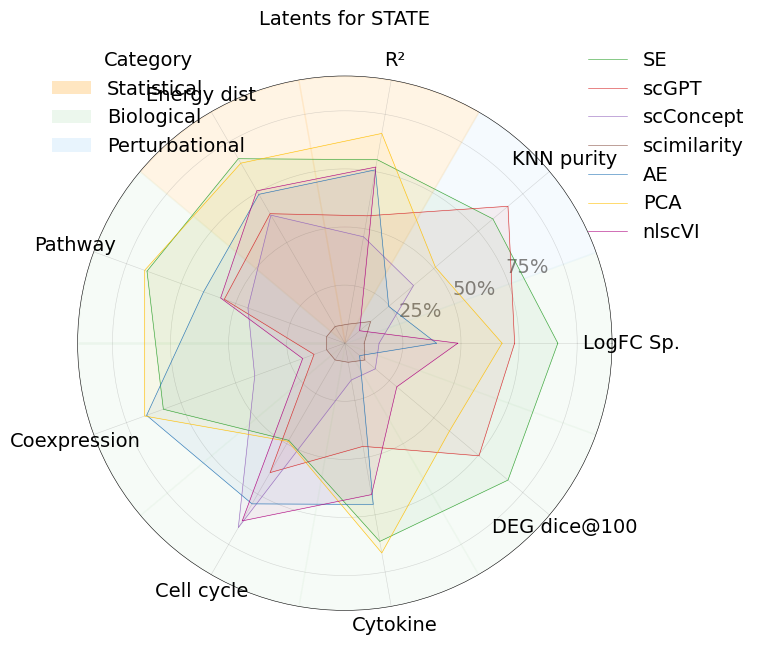

In [5]:
RADAR_METRICS = [
    ("deg", "pred_mean_genediff_spearman", "wilcoxon", "LogFC Sp.", True, "Biological"),
    ("distributional", "knn_purity_norm", None, "KNN purity", True, "Perturbational"),
    ("distributional", "r2_score", None, "R\u00b2", True, "Statistical"),
    ("distributional", "energy_distance", None, "Energy dist", False, "Statistical"),
    ("pathway", "average", "spearman", "Pathway", True, "Biological"),
    ("coexpression", "average", "spearman", "Coexpression", True, "Biological"),
    ("cellcycle", "proportion_same_phase", None, "Cell cycle", True, "Biological"),
    ("cytokine", "average", "spearman", "Cytokine", True, "Biological"),
    ("deg", "pred_deg_dice_100", "wilcoxon", "DEG dice@100", True, "Biological"),


]

CAT_COLORS = {
    "Statistical":  "#FFE0B2",
    "Biological":      "#E8F5E9",
    "Perturbational":  "#E3F2FD",
}

RADAR_LABEL_MAP = {
    "R\u00b2": "$R^2$",
    "Energy dist": "Energy distance",
    "Pathway": "Pathway Spearman",
    "KNN purity": "KNN purity (normalized)",
    "Cytokine": "Cytokine Spearman",
    "Coexpression": "Coexpression Spearman",
    "Cell cycle": "Cell-cycle (same phase)",
    "DEG dice@100": "DEG dice@100 (pred)",
    "LogFC Sp.": "Mean gene-diff Spearman",
}

BASELINE_LATENTS = {"AE": 2048, "PCA": 2048, "nlscVI": 128}


def plot_radar(dw="0.1", ckpt="best"):
    radar_labels = [m[3] for m in RADAR_METRICS]
    radar_cats = [m[5] for m in RADAR_METRICS]
    radar_higher = [m[4] for m in RADAR_METRICS]
    df_labels = [RADAR_LABEL_MAP[l] for l in radar_labels]

    sub = df_all[(df_all["dw"] == dw) & (df_all["ckpt"] == ckpt)
               & (df_all["metric"].isin(df_labels))].copy()

    models = {}
    for fm in FM_MODELS:
        vals = sub[(sub["model"] == fm) & (sub["is_fm"])].set_index("metric")["mean"]
        if not vals.empty:
            models[fm] = vals
    for base, latent in BASELINE_LATENTS.items():
        vals = sub[(sub["model"] == base) & (sub["latent"] == latent)
                   & (~sub["is_fm"])].set_index("metric")["mean"]
        if not vals.empty:
            models[f"{base}_{latent}"] = vals

    if not models:
        print("No data for radar")
        return

    all_vals = pd.DataFrame(models)
    metric_min = all_vals.min(axis=1)
    metric_max = all_vals.max(axis=1)
    metric_range = metric_max - metric_min
    metric_range = metric_range.replace(0, 1)
    metric_min_pad = metric_min - 0.1 * metric_range
    metric_max_pad = metric_max + 0.1 * metric_range

    def norm(metric_df_label, value, higher_is_better=True):
        n = (value - metric_min_pad[metric_df_label]) / (
            metric_max_pad[metric_df_label] - metric_min_pad[metric_df_label])
        return n if higher_is_better else 1 - n

    n = len(radar_labels)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    sector_width = 2 * np.pi / n
    for i, cat in enumerate(radar_cats):
        theta_start = angles[i] - sector_width / 2
        ax.fill_between(
            np.linspace(theta_start, theta_start + sector_width, 30),
            0, 1.15,
            color=CAT_COLORS[cat], alpha=0.35, zorder=0,
        )

    LEGEND_NAMES = {f"{b}_{l}": b for b, l in BASELINE_LATENTS.items()}

    all_colors = {**SCALING_COLORS, **FM_COLORS,
                  **{f"{b}_{l}": SCALING_COLORS[b]
                     for b, l in BASELINE_LATENTS.items() if b in SCALING_COLORS}}
    for model_name, vals in models.items():
        values = [norm(RADAR_LABEL_MAP[l], vals.get(RADAR_LABEL_MAP[l], np.nan), h)
                  for l, h in zip(radar_labels, radar_higher)]
        values += values[:1]
        color = all_colors.get(model_name, "gray")
        display_name = LEGEND_NAMES.get(model_name, model_name)
        ax.plot(angles, values, lw=0.4, label=display_name, color=color, zorder=3)
        ax.fill(angles, values, alpha=0.06, color=color, zorder=2)

    ax.set_thetagrids([a * 180 / np.pi for a in angles[:-1]], radar_labels, fontsize=14)
    ax.set_ylim(0, 1.15)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["25%", "50%", "75%", ""], fontsize=14, color="gray")
    ax.spines["polar"].set_linewidth(0.4)
    from matplotlib.patches import Patch
    cat_handles = [Patch(facecolor=CAT_COLORS[c], alpha=0.8, label=c)
                   for c in ["Statistical", "Biological", "Perturbational"]]
    leg1 = ax.legend(handles=cat_handles, loc="upper left",
                     bbox_to_anchor=(-0.08, 1.08), fontsize=14, frameon=False,
                     title="Category", title_fontsize=14)
    ax.add_artist(leg1)
    ax.yaxis.grid(linewidth=0.4, color="gray", alpha=0.3)
    ax.xaxis.grid(linewidth=0.4, color="gray", alpha=0.3)
    ax.spines["polar"].set_linewidth(0.4)

    ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.08), fontsize=14, frameon=False)

    ax.set_title("Latents for STATE", y=1.08, fontsize=14)
    plt.tight_layout(pad=0.5)
    plt.savefig("../figs/fig4/radar_st_scaling.svg", bbox_inches="tight")
    plt.show()

with plt.rc_context({"font.size": 30}):
    plot_radar("0.1", ckpt=CKPT)

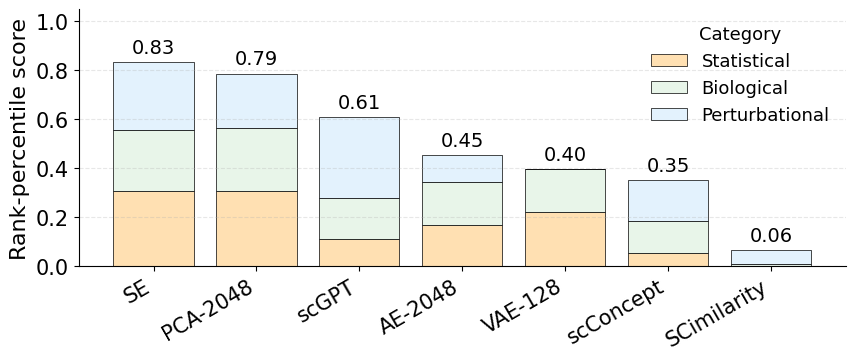


Per-model rank-percentile scores:


,Statistical,Biological,Perturbational,total
label,,,,
SE,0.917,0.750,0.833,0.833
PCA-2048,0.917,0.778,0.667,0.787
scGPT,0.333,0.500,1.000,0.611
AE-2048,0.500,0.528,0.333,0.454
VAE-128,0.667,0.528,0.000,0.398
scConcept,0.167,0.389,0.500,0.352
SCimilarity,0.000,0.028,0.167,0.065


In [6]:
def plot_overall_bar(out_svg=None, dw="0.1", ckpt=CKPT):
    """Vertical stacked bar: one bar per model, 3 segments = category percentiles / 3."""
    sub = df_all[(df_all["dw"] == dw) & (df_all["ckpt"] == ckpt)].copy()
    sub["key"] = sub.apply(
        lambda r: f"{r['model']}_{int(r['latent'])}" if not r["is_fm"] else r["model"],
        axis=1,
    )

    LEGEND_NAMES = {
        f"{b}_{l}": label
        for (b, l), label in zip(BASELINE_LATENTS.items(),
                                 [f"{b}-{l}" for b, l in BASELINE_LATENTS.items()])
    }

    PRETTY_BASE = {"AE": "AE", "PCA": "PCA", "nlscVI": "VAE"}
    LEGEND_NAMES = {f"{b}_{l}": f"{PRETTY_BASE.get(b, b)}-{l}"
                    for b, l in BASELINE_LATENTS.items()}
    LEGEND_NAMES["scimilarity"] = "SCimilarity"

    radar_keys = list(FM_MODELS.keys()) + [f"{b}_{l}" for b, l in BASELINE_LATENTS.items()]
    sub_filt = sub[sub["key"].isin(radar_keys)].copy()

    CAT_ORDER = ["Statistical", "Biological", "Perturbational"]

    cat_scores = {}
    for cat_name, cat_metrics in RANK_CATEGORIES.items():
        rank_df = pd.DataFrame()
        for metric_label, higher_better in cat_metrics.items():
            mv = sub_filt[sub_filt["metric"] == metric_label][["key", "mean"]].dropna(subset=["mean"])
            if mv.empty:
                continue
            mv = mv.set_index("key")["mean"]

            M = mv.notna().sum()
            if M < 2 or mv.nunique() <= 1:
                rank_df[metric_label] = pd.Series(float("nan"), index=mv.index)
            else:
                _r = mv.rank(method="average", ascending=(not higher_better))
                rank_df[metric_label] = (M - _r) / (M - 1)
        if rank_df.empty:
            continue
        cat_scores[cat_name] = rank_df.mean(axis=1)

    pivot = pd.DataFrame(cat_scores).reindex(columns=CAT_ORDER).fillna(0)

    rows = []
    for k, vals in pivot.iterrows():
        rows.append({"key": k,
                     "label": LEGEND_NAMES.get(k, k),
                     **{c: float(vals[c]) for c in CAT_ORDER}})
    df_bar = pd.DataFrame(rows)
    n_cats = len(CAT_ORDER)
    df_bar["total"] = df_bar[CAT_ORDER].mean(axis=1)
    df_bar = df_bar.sort_values("total", ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(0.85 * len(df_bar) + 2.5, 3.5))
    x = np.arange(len(df_bar))
    bottom = np.zeros(len(df_bar))
    for cat in CAT_ORDER:
        vals = df_bar[cat].to_numpy() / n_cats
        ax.bar(x, vals, bottom=bottom, color=CAT_COLORS[cat],
               edgecolor="black", linewidth=0.5, width=0.78, label=cat)
        bottom += vals

    for i, t in enumerate(df_bar["total"].to_numpy()):
        ax.text(i, t + 0.02, f"{t:.2f}",
                ha="center", va="bottom", fontsize=14)

    ax.set_xticks(x)
    ax.set_xticklabels(df_bar["label"].tolist(), rotation=30, ha="right", fontsize=16)
    ax.set_ylabel("Rank-percentile score", fontsize=16)
    ax.set_ylim(0, 1.05)
    ax.tick_params(labelsize=15)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.grid(axis="y", ls="--", alpha=0.3)
    ax.legend(loc="upper right", fontsize=13, frameon=False, title="Category",
              title_fontsize=13)

    plt.tight_layout(pad=0.3)
    if out_svg:
        plt.savefig(out_svg, bbox_inches="tight")
    plt.show()
    return df_bar


df_bar = plot_overall_bar(
    out_svg="../figs/fig4/bar_st_scaling.svg",
    dw="0.1", ckpt=CKPT,
)
print("\nPer-model rank-percentile scores:")
display(df_bar.set_index("label")[["Statistical", "Biological", "Perturbational", "total"]].round(3))

# CellFlow Perturbation Model — Scaling Evaluation

Systematic evaluation of CellFlow (flow matching) model performance across latent sizes.

**Layout:**
- Scaling lines (AE, VAE, PCA) across latent dims 10→2048
- Foundation model dots (SE, scGPT, scConcept, scimilarity) at their native dim
- Confidence bands from 5 seeds
- Per-cell-type breakdown for key metrics

## 1. Config

In [7]:
CKPT = "last"

SCALING_MODELS = {
    "AE":    [10, 32, 128, 512, 2048],
    "nlscVI": [10, 32, 128, 512, 2048],
    "PCA":   [10, 32, 128, 512, 2048],
}

FM_MODELS = {
    "SE":          2058,
    "scGPT":       512,
    "scConcept":   512,
    "scimilarity": 128,
}

SCALING_COLORS = {"AE": "#2171b5", "nlscVI": "#ae017e", "PCA": "#ffbf00"}
SCALING_MARKERS = {"AE": "o", "nlscVI": "s", "PCA": "D"}
FM_COLORS = {"SE": "#2ca02c", "scGPT": "#d62728", "scConcept": "#9467bd", "scimilarity": "#8c564b"}
FM_MARKERS = {"SE": "*", "scGPT": "P", "scConcept": "X", "scimilarity": "^"}
FM_DISPLAY = {"SE": "SE", "scGPT": "scGPT", "scConcept": "scConcept", "scimilarity": "SCimilarity"}

## 2. Data Loading

In [8]:
METRICS = [
    ("distributional", "r2_score", None, "$R^2$", True),
    ("distributional", "energy_distance", None, "Energy distance", False),
    ("distributional", "mmd_rbf", None, "MMD-RBF", False),
    ("distributional", "knn_purity_10", None, "KNN purity (k=10)", True),
    ("distributional", "knn_purity_norm", None, "KNN purity (normalized)", True),
    ("pathway", "average", "spearman", "Pathway Spearman", True),
    ("coexpression", "average", "spearman", "Coexpression Spearman", True),
    ("cellcycle", "proportion_same_phase", None, "Cell-cycle (same phase)", True),
    ("deg", "pred_deg_dice_100", "wilcoxon", "DEG dice@100 (pred)", True),
    ("deg", "pred_mean_genediff_spearman", "wilcoxon", "Mean gene-diff Spearman", True),
    ("cytokine", "average", "spearman", "Cytokine Spearman", True),
]

df_all = pd.read_csv("../frozen/figs/decoder_only_cf.csv")

## 3. Aggregate Rank Scores

Rank-based aggregation: for each metric, rank all (model, latent) entries 1–N, then average ranks within category.
- **Statistical**: $R^2$, Energy distance
- **Biological**: Cell-cycle, DEG dice@100, Mean gene-diff Spearman, Coexpression Spearman, Pathway Spearman
- **Perturbational**: KNN purity (normalized)

Higher score = better.

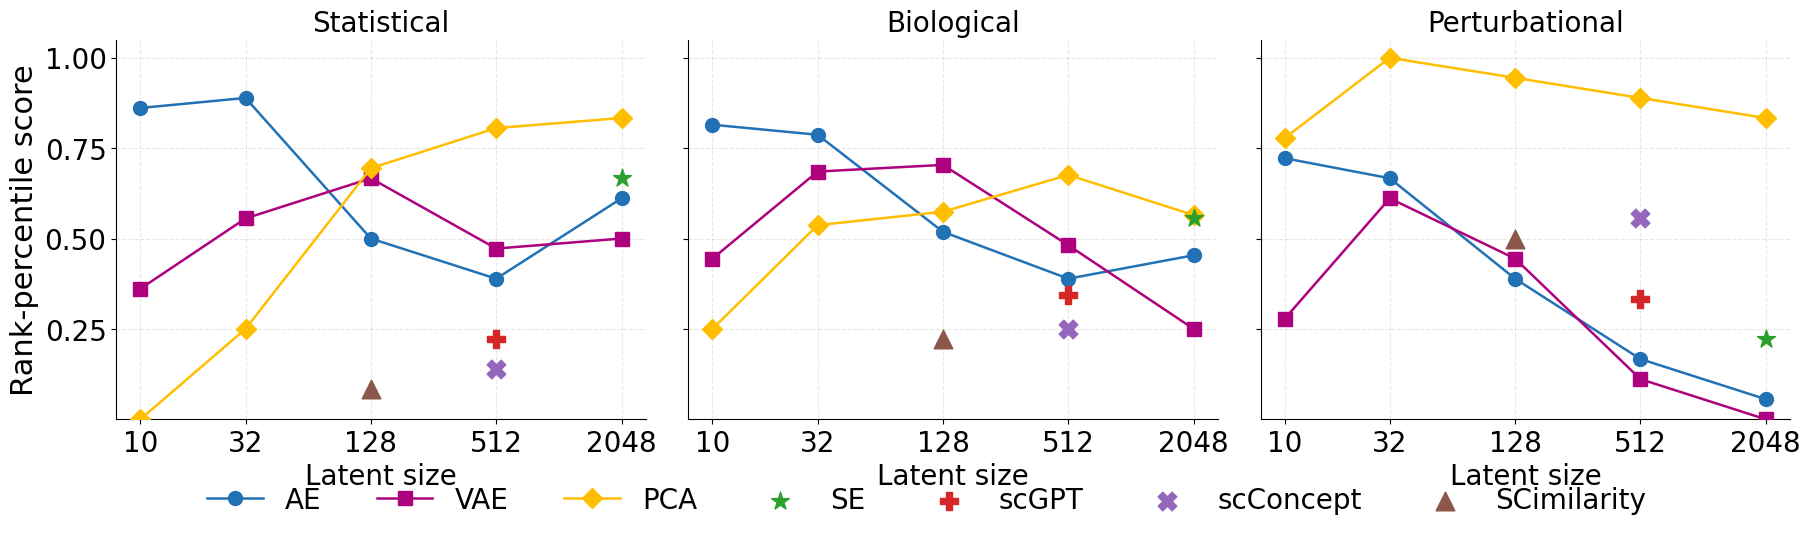


Aggregate scores (higher = better):


category                  Biological  Perturbational  Statistical  Overall
model       latent is_fm                                                  
AE          10     False         0.8             0.7          0.9      0.8
PCA         512    False         0.7             0.9          0.8      0.8
AE          32     False         0.8             0.7          0.9      0.8
PCA         2048   False         0.6             0.8          0.8      0.7
            128    False         0.6             0.9          0.7      0.7
nlscVI      32     False         0.7             0.6          0.6      0.6
            128    False         0.7             0.4          0.7      0.6
PCA         32     False         0.5             1.0          0.2      0.6
SE          2058   True          0.6             0.2          0.7      0.5
AE          128    False         0.5             0.4          0.5      0.5
            2048   False         0.5             0.1          0.6      0.4
nlscVI      10     False         0.4             0.3          0.4      0.4
            512    False         0.5             0.1          0.5      0.4
PCA         10     False         0.2             0.8          0.0      0.3
AE          512    False         0.4             0.2          0.4      0.3
scConcept   512    True          0.2             0.6          0.1      0.3
scGPT       512    True          0.3             0.3          0.2      0.3
scimilarity 128    True          0.2             0.5          0.1      0.3
nlscVI      2048   False         0.3             0.0          0.5      0.2

In [9]:
RANK_CATEGORIES = {
    "Statistical": {
        "$R^2$": True,
        "Energy distance": False,
    },
    "Biological": {
        "Cell-cycle (same phase)": True,
        "DEG dice@100 (pred)": True,
        "Mean gene-diff Spearman": True,
        "Coexpression Spearman": True,
        "Pathway Spearman": True,
        "Cytokine Spearman": True,
    },
    "Perturbational": {
        "KNN purity (normalized)": True,
    },
}


def compute_aggregate_ranks(df_all):
    sub = df_all.copy()
    sub["key"] = sub.apply(
        lambda r: f"{r['model']}_{int(r['latent'])}" if not r["is_fm"] else r["model"], axis=1
    )
    results = []
    for cat_name, cat_metrics in RANK_CATEGORIES.items():
        rank_df = pd.DataFrame()
        for metric_label, higher_better in cat_metrics.items():
            metric_vals = sub[sub["metric"] == metric_label][["key", "mean"]].dropna(subset=["mean"])
            if metric_vals.empty:
                continue
            metric_vals = metric_vals.set_index("key")["mean"]
            M = metric_vals.notna().sum()
            if M < 2 or metric_vals.nunique() <= 1:
                ranks = pd.Series(float("nan"), index=metric_vals.index)
            else:
                _r = metric_vals.rank(method="average", ascending=(not higher_better))
                ranks = (M - _r) / (M - 1)
            rank_df[metric_label] = ranks
        if rank_df.empty:
            continue
        avg_rank = rank_df.mean(axis=1)
        max_rank = avg_rank.max()
        for key, rank in avg_rank.items():
            row = sub[sub["key"] == key].iloc[0]
            results.append({
                "model": row["model"], "latent": row["latent"],
                "is_fm": row["is_fm"], "category": cat_name,
                "avg_rank": rank,
                "avg_score": rank,
                "n_metrics": rank_df.loc[key].notna().sum(),
            })
    return pd.DataFrame(results)


df_ranks = compute_aggregate_ranks(df_all)

cats = list(RANK_CATEGORIES.keys())
fig, axes = plt.subplots(1, len(cats), figsize=(18, 5.2), sharey=True)

if len(cats) == 1:
    axes = [axes]

for idx, (ax, cat) in enumerate(zip(axes, cats)):
    cat_df = df_ranks[df_ranks["category"] == cat]

    for base in SCALING_MODELS:
        ss = cat_df[(cat_df["model"] == base) & (~cat_df["is_fm"])].sort_values("latent")
        if ss.empty:
            continue
        ax.plot(ss["latent"], ss["avg_score"],
                color=SCALING_COLORS[base], marker=SCALING_MARKERS[base],
                lw=1.8, ms=10, label=SCALING_DISPLAY.get(base, base), zorder=3)

    for fm in FM_MODELS:
        ss = cat_df[(cat_df["model"] == fm) & (cat_df["is_fm"])]
        if ss.empty:
            continue
        row = ss.iloc[0]
        ax.scatter(row["latent"], row["avg_score"],
                   color=FM_COLORS[fm], marker=FM_MARKERS[fm],
                   s=180, label=FM_DISPLAY.get(fm, fm), zorder=4)

    ax.set_xlabel("Latent size", fontsize=20)
    if idx == 0:
        ax.set_ylabel("Rank-percentile score", fontsize=22)
    ax.set_title(cat, fontsize=20)
    ax.set_xscale("log", base=2)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_xticks([10, 32, 128, 512, 2048])
    ax.tick_params(labelsize=20)
    ax.grid(True, ls="--", alpha=0.3)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

for ax in axes:
    ax.set_ylim(0, 1.05)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(labels),
           fontsize=20, frameon=False, bbox_to_anchor=(0.5, -0.08))

plt.subplots_adjust(left=0.05, right=0.98, bottom=0.15, top=0.88, wspace=0.08)
fig.savefig("../figs/fig4/aggregate_ranks_cf.svg", bbox_inches="tight")
plt.show()

rank_pivot = df_ranks.pivot_table(index=["model", "latent", "is_fm"],
                                   columns="category", values="avg_score")
rank_pivot["Overall"] = rank_pivot.mean(axis=1)
rank_pivot = rank_pivot.sort_values("Overall", ascending=False)
print("\nAggregate scores (higher = better):")
display(rank_pivot.round(1))

## 4. Radar Plot: FM Comparison at Native Dim

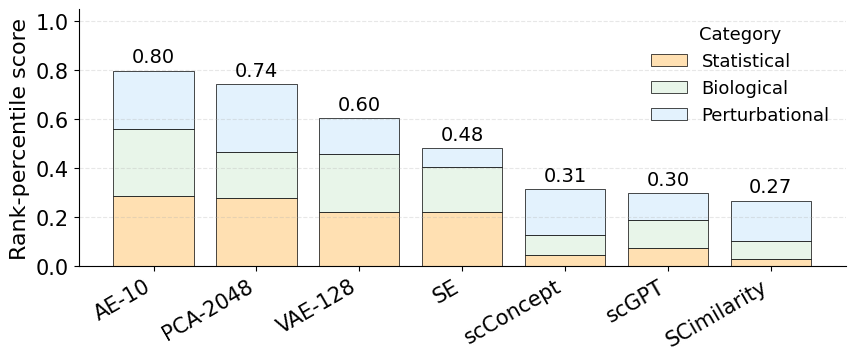

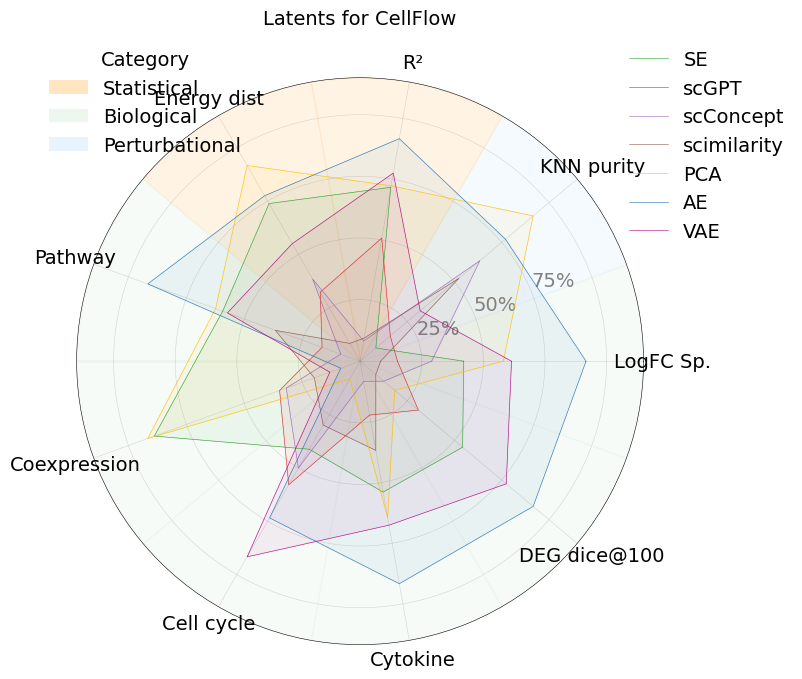

In [10]:
RADAR_METRICS = [
    ("deg", "pred_mean_genediff_spearman", "wilcoxon", "LogFC Sp.", True, "Biological"),
    ("distributional", "knn_purity_norm", None, "KNN purity", True, "Perturbational"),
    ("distributional", "r2_score", None, "R\u00b2", True, "Statistical"),
    ("distributional", "energy_distance", None, "Energy dist", False, "Statistical"),
    ("pathway", "average", "spearman", "Pathway", True, "Biological"),
    ("coexpression", "average", "spearman", "Coexpression", True, "Biological"),
    ("cellcycle", "proportion_same_phase", None, "Cell cycle", True, "Biological"),
    ("cytokine", "average", "spearman", "Cytokine", True, "Biological"),
    ("deg", "pred_deg_dice_100", "wilcoxon", "DEG dice@100", True, "Biological"),


]

CAT_COLORS = {
    "Statistical":  "#FFE0B2",
    "Biological":      "#E8F5E9",
    "Perturbational":  "#E3F2FD",
}

RADAR_LABEL_MAP = {
    "R\u00b2": "$R^2$",
    "Energy dist": "Energy distance",
    "Pathway": "Pathway Spearman",
    "KNN purity": "KNN purity (normalized)",
    "Coexpression": "Coexpression Spearman",
    "Cell cycle": "Cell-cycle (same phase)",
    "DEG dice@100": "DEG dice@100 (pred)",
    "LogFC Sp.": "Mean gene-diff Spearman",
    "Cytokine": "Cytokine Spearman",
}


def _gather_models_for_bar_radar():
    """Same set of models used in radar/bar — keep the two plots synced."""
    radar_labels = [m[3] for m in RADAR_METRICS]
    df_labels = [RADAR_LABEL_MAP[l] for l in radar_labels]
    sub = df_all[df_all["metric"].isin(df_labels)].copy()

    models = {}
    for fm in FM_MODELS:
        vals = sub[(sub["model"] == fm) & (sub["is_fm"])].set_index("metric")["mean"]
        if not vals.empty:
            models[fm] = vals
    for base, lat in [("PCA", 2048), ("AE", 10), ("nlscVI", 128)]:
        vals = sub[(sub["model"] == base) & (sub["latent"] == lat)
                   & (~sub["is_fm"])].set_index("metric")["mean"]
        if not vals.empty:
            models[f"{base}_{lat}"] = vals
    return models


def plot_overall_bar(out_svg=None):
    """Vertical stacked bar: one bar per model on x, 3 segments = category avg-rank scores."""
    models = _gather_models_for_bar_radar()
    if not models:
        print("No data for bar")
        return

    LEGEND_NAMES = {
        "PCA_2048":   "PCA-2048",
        "AE_10":      "AE-10",
        "nlscVI_128": "VAE-128",
        "scimilarity": "SCimilarity",
    }
    CAT_ORDER = ["Statistical", "Biological", "Perturbational"]

    rows = []
    for key in models.keys():
        if "_" in key and key.split("_")[-1].isdigit():
            base, lat = key.rsplit("_", 1); lat = int(lat); is_fm = False
        else:
            base, lat, is_fm = key, None, True
        if is_fm:
            cs = df_ranks[(df_ranks["model"] == base) & (df_ranks["is_fm"])]
        else:
            cs = df_ranks[(df_ranks["model"] == base) & (df_ranks["latent"] == lat)
                          & (~df_ranks["is_fm"])]
        if cs.empty:
            continue
        per_cat = cs.groupby("category")["avg_score"].mean().to_dict()
        rows.append({"key": key,
                     "label": LEGEND_NAMES.get(key, key),
                     **{c: per_cat.get(c, 0.0) for c in CAT_ORDER}})

    df_bar = pd.DataFrame(rows)
    n_cats = len(CAT_ORDER)
    df_bar["total"] = df_bar[CAT_ORDER].mean(axis=1)
    df_bar = df_bar.sort_values("total", ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(0.85 * len(df_bar) + 2.5, 3.5))
    x = np.arange(len(df_bar))
    bottom = np.zeros(len(df_bar))
    for cat in CAT_ORDER:
        vals = df_bar[cat].to_numpy() / n_cats
        ax.bar(x, vals, bottom=bottom, color=CAT_COLORS[cat],
               edgecolor="black", linewidth=0.5, width=0.78, label=cat)
        bottom += vals

    for i, t in enumerate(df_bar["total"].to_numpy()):
        ax.text(i, t + 0.02 * df_bar["total"].max(), f"{t:.2f}",
                ha="center", va="bottom", fontsize=14)

    ax.set_xticks(x)
    ax.set_xticklabels(df_bar["label"].tolist(), rotation=30, ha="right", fontsize=16)
    ax.set_ylabel("Rank-percentile score", fontsize=16)
    ax.set_ylim(0, 1.05)
    ax.tick_params(labelsize=15)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.grid(axis="y", ls="--", alpha=0.3)
    ax.legend(loc="upper right", fontsize=13, frameon=False, title="Category",
              title_fontsize=13)

    plt.tight_layout(pad=0.3)
    if out_svg:
        plt.savefig(out_svg, bbox_inches="tight")
    plt.show()


def plot_radar():
    radar_labels = [m[3] for m in RADAR_METRICS]
    radar_cats = [m[5] for m in RADAR_METRICS]
    radar_higher = [m[4] for m in RADAR_METRICS]
    df_labels = [RADAR_LABEL_MAP[l] for l in radar_labels]

    sub = df_all[df_all["metric"].isin(df_labels)].copy()
    models = _gather_models_for_bar_radar()
    if not models:
        print("No data for radar")
        return

    all_vals = pd.DataFrame(models)
    metric_min = all_vals.min(axis=1)
    metric_max = all_vals.max(axis=1)
    metric_range = (metric_max - metric_min).replace(0, 1)
    metric_min_pad = metric_min - 0.1 * metric_range
    metric_max_pad = metric_max + 0.1 * metric_range

    def norm(metric_df_label, value, higher_is_better=True):
        n = (value - metric_min_pad[metric_df_label]) / (
            metric_max_pad[metric_df_label] - metric_min_pad[metric_df_label])
        return n if higher_is_better else 1 - n

    n = len(radar_labels)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles += angles[:1]

    LEGEND_NAMES = {"PCA_2048": "PCA", "AE_10": "AE", "nlscVI_128": "VAE"}
    all_colors = {**SCALING_COLORS, **FM_COLORS,
                  "PCA_2048": SCALING_COLORS["PCA"],
                  "AE_10": SCALING_COLORS["AE"],
                  "nlscVI_128": SCALING_COLORS["nlscVI"]}

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(1, 1, 1, polar=True)

    sector_width = 2 * np.pi / n
    for i, cat in enumerate(radar_cats):
        theta_start = angles[i] - sector_width / 2
        ax.fill_between(
            np.linspace(theta_start, theta_start + sector_width, 30),
            0, 1.15,
            color=CAT_COLORS[cat], alpha=0.35, zorder=0,
        )

    for model_name, vals in models.items():
        values = [norm(RADAR_LABEL_MAP[l], vals.get(RADAR_LABEL_MAP[l], np.nan), h)
                  for l, h in zip(radar_labels, radar_higher)]
        values += values[:1]
        color = all_colors.get(model_name, "gray")
        display_name = LEGEND_NAMES.get(model_name, model_name)
        ax.plot(angles, values, lw=0.4, label=display_name, color=color, zorder=3)
        ax.fill(angles, values, alpha=0.06, color=color, zorder=2)

    ax.set_thetagrids([a * 180 / np.pi for a in angles[:-1]], radar_labels, fontsize=14)
    ax.set_ylim(0, 1.15)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["25%", "50%", "75%", ""], fontsize=14, color="gray")
    ax.spines["polar"].set_linewidth(0.4)
    ax.yaxis.grid(linewidth=0.4, color="gray", alpha=0.3)
    ax.xaxis.grid(linewidth=0.4, color="gray", alpha=0.3)

    from matplotlib.patches import Patch
    cat_handles = [Patch(facecolor=CAT_COLORS[c], alpha=0.8, label=c)
                   for c in ["Statistical", "Biological", "Perturbational"]]
    leg1 = ax.legend(handles=cat_handles, loc="upper left",
                     bbox_to_anchor=(-0.08, 1.08), fontsize=14, frameon=False,
                     title="Category", title_fontsize=14)
    ax.add_artist(leg1)
    ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.08), fontsize=14, frameon=False)

    ax.set_title("Latents for CellFlow", y=1.08, fontsize=14)
    plt.tight_layout(pad=0.3)
    plt.savefig("../figs/fig4/radar_cf_scaling.svg", bbox_inches="tight")
    plt.show()


plot_overall_bar(out_svg="../figs/fig4/bar_cf_scaling.svg")
plot_radar()

# ST Quality Check

Evaluate a trained STATE model on PBMC perturbation data.  
All donors pooled; sets built per **(cytokine, cell-type)** pair.

In [11]:
MODEL_NAME   = "nlscVI_32"
BATCH_SIZE   = 8
CELL_SET_LEN = 512

PERT_COL  = "target_gene"
DONOR_COL = "donor"
CT_COL    = "cell_type"
CONTROL   = "PBS"

EVAL_SPLIT = "test"
MAX_SETS   = 2000
CKPT_SETS  = 40

SVG_DIR = "../figs/fig4"
os.makedirs(SVG_DIR, exist_ok=True)
SOURCE_PALETTE = {"ctrl": "#3F65A6", "pert_true": "#E78776", "pred": "#AFE3E4"}

--- 
## Single-cell-type spotlight UMAP (B cells)

For each of the two focal perturbations (CD40L, IL-4), plot UMAP restricted to
B cells only — ctrl / true / pred highlighted in the same colour scheme as above.
Computed in both latent and decoded gene space.

In [12]:
with open("../frozen/st_umaps_vae32.pkl", "rb") as f:
    res_bcell = pickle.load(f)
    f.close()

In [13]:
FOCUS_CT    = "CD14_Mono"
FOCUS_PERTS = ["IFN_beta"]
UMAP_MAX_PER_GROUP = 200


Computing CD14_Mono UMAP — Latent (nlscVI_32)  (1 highlighted perts) ...
  UMAP input: 50,208 cells (focus kept full, others ≤200/group)
  Saved -> ../figs/fig4/umap_test_emb_CD14_Monoct_IFN_beta_3panel_nlscVI_32.svg


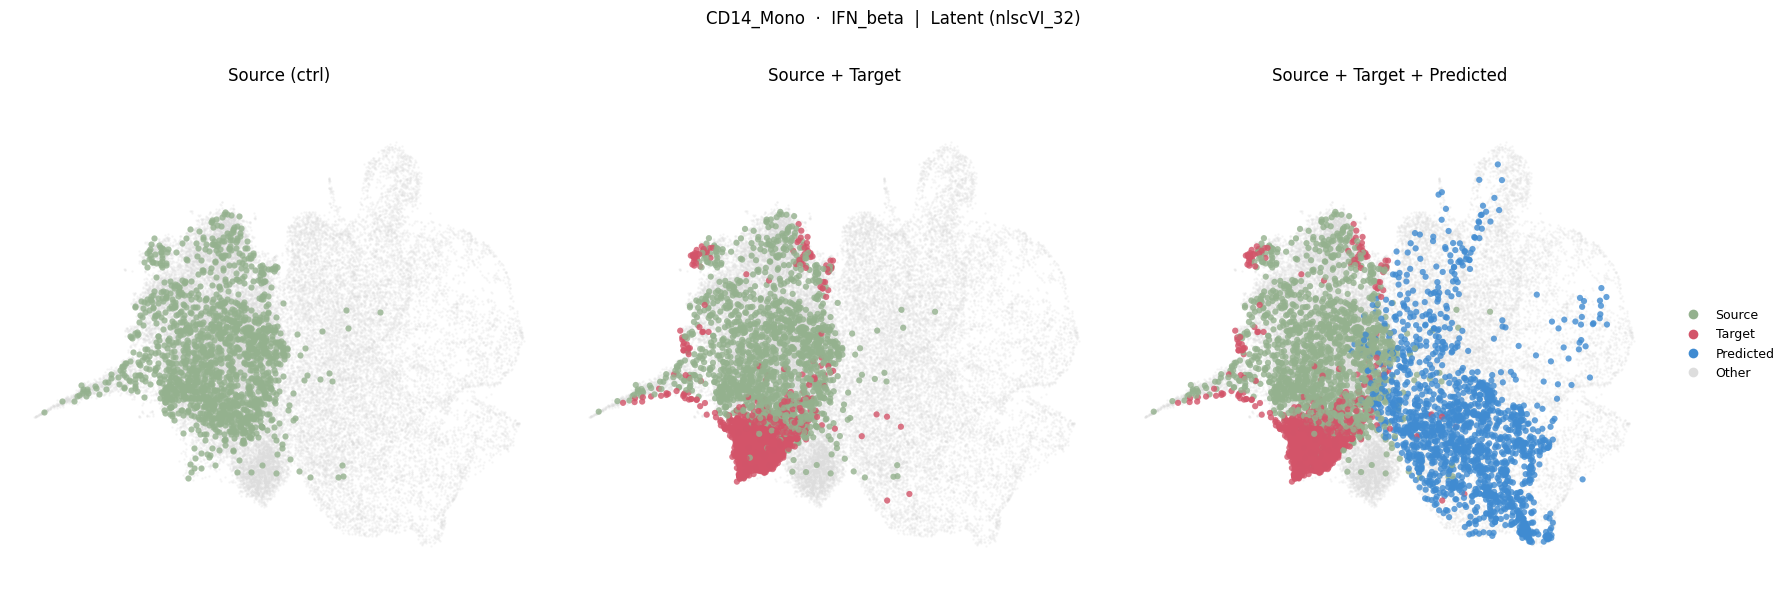


Computing CD14_Mono UMAP — Gene space (decoded)  (1 highlighted perts) ...
  UMAP input: 50,208 cells (focus kept full, others ≤200/group)
  Saved -> ../figs/fig4/umap_test_gene_CD14_Monoct_IFN_beta_3panel_nlscVI_32.svg


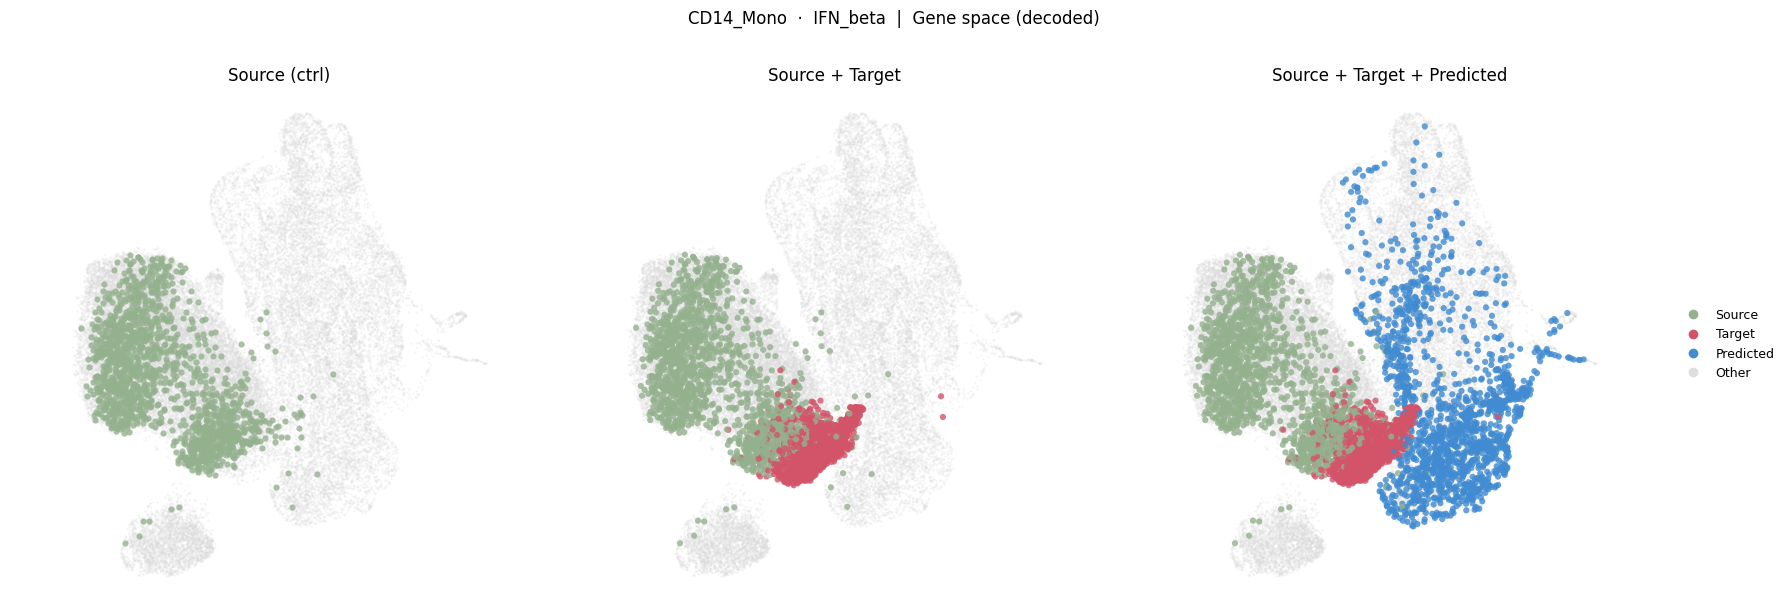

In [14]:
def make_umap_bcell(res, space, cell_type, focus_perts,
                    max_per_group=200, seed=42):
    """UMAP on a single cell-type. Subsample non-focus perts to max_per_group
    cells per (source, pert) to keep UMAP tractable; focus perts kept in full."""
    keys = {
        "emb":  ("ctrl_emb", "pert_emb", "pred_emb"),
        "gene": ("ctrl_gene", "pert_gene", "pred_gene"),
    }[space]
    rng    = np.random.default_rng(seed)
    ct_arr = np.array(res["cell_type"])
    pt_arr = np.array(res["pert_name"])

    parts, sources, perts_col = [], [], []
    for arr, src in zip([res[k] for k in keys], ["ctrl", "pert_true", "pred"]):
        base_idx = np.where(ct_arr == cell_type)[0]
        for pert in np.unique(pt_arr[base_idx]):
            idx = base_idx[pt_arr[base_idx] == pert]
            if pert not in focus_perts and len(idx) > max_per_group:
                idx = rng.choice(idx, max_per_group, replace=False)
            parts.append(arr[idx].astype(np.float32))
            sources.extend([src] * len(idx))
            perts_col.extend([pert] * len(idx))

    X       = np.concatenate(parts, axis=0)
    obs_df  = pd.DataFrame({"source": sources, "pert_name": perts_col})
    adata_u = ad.AnnData(X=X, obs=obs_df)
    adata_u.obs_names = [str(i) for i in range(len(adata_u))]
    n_pcs = min(50, adata_u.n_obs - 1, adata_u.n_vars - 1)
    sc.pp.pca(adata_u, n_comps=n_pcs)
    sc.pp.neighbors(adata_u, n_pcs=n_pcs)
    sc.tl.umap(adata_u)
    print(f"  UMAP input: {len(adata_u):,} cells "
          f"(focus kept full, others ≤{max_per_group}/group)")
    return adata_u

DOT_SIZE = 20
DOT_ALPHA = 0.8
SOURCE_PALETTE = {"ctrl": "#94B18E", "pert_true": "#D35469", "pred": "#408BD1"}

for space, label in [("emb", f"Latent ({MODEL_NAME})"), ("gene", "Gene space (decoded)")]:
    ct_mask   = np.array(res_bcell["cell_type"]) == FOCUS_CT
    available = [p for p in FOCUS_PERTS
                 if p in set(np.array(res_bcell["pert_name"])[ct_mask])]
    if not available:
        print(f"No {FOCUS_CT!r} data for {FOCUS_PERTS} — skipping {label}")
        continue

    print(f"\nComputing {FOCUS_CT} UMAP — {label}  ({len(available)} highlighted perts) ...")
    adata_u = make_umap_bcell(res_bcell, space, FOCUS_CT,
                              focus_perts=available,
                              max_per_group=UMAP_MAX_PER_GROUP)
    coords  = adata_u.obsm["X_umap"]

    for pert in available:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        bg = ~np.isin(adata_u.obs["pert_name"].values, [pert])
        fg_ctrl = ((adata_u.obs["source"] == "ctrl") & (adata_u.obs["pert_name"] == pert)).values
        fg_true = ((adata_u.obs["source"] == "pert_true") & (adata_u.obs["pert_name"] == pert)).values
        fg_pred = ((adata_u.obs["source"] == "pred") & (adata_u.obs["pert_name"] == pert)).values

        ax = axes[0]
        ax.scatter(coords[bg, 0], coords[bg, 1],
                   c="#dddddd", s=1, alpha=0.15, rasterized=True, zorder=1)
        ax.scatter(coords[fg_ctrl, 0], coords[fg_ctrl, 1],
                   c=SOURCE_PALETTE["ctrl"], s=DOT_SIZE, alpha=DOT_ALPHA,
                   rasterized=True, zorder=2, linewidths=0)
        ax.set_title(f"Source (ctrl)")

        ax = axes[1]
        ax.scatter(coords[bg, 0], coords[bg, 1],
                   c="#dddddd", s=1, alpha=0.15, rasterized=True, zorder=1)
        fg = fg_ctrl | fg_true
        fg_idx = np.where(fg)[0]
        np.random.default_rng(42).shuffle(fg_idx)
        fg_colors = [SOURCE_PALETTE[adata_u.obs.iloc[i]["source"]] for i in fg_idx]
        ax.scatter(coords[fg_idx, 0], coords[fg_idx, 1],
                   c=fg_colors, s=DOT_SIZE, alpha=DOT_ALPHA,
                   rasterized=True, zorder=2, linewidths=0)
        ax.set_title(f"Source + Target")

        ax = axes[2]
        ax.scatter(coords[bg, 0], coords[bg, 1],
                   c="#dddddd", s=1, alpha=0.15, rasterized=True, zorder=1)
        fg = fg_ctrl | fg_true | fg_pred
        fg_idx = np.where(fg)[0]
        np.random.default_rng(42).shuffle(fg_idx)
        fg_colors = [SOURCE_PALETTE[adata_u.obs.iloc[i]["source"]] for i in fg_idx]
        ax.scatter(coords[fg_idx, 0], coords[fg_idx, 1],
                   c=fg_colors, s=DOT_SIZE, alpha=DOT_ALPHA,
                   rasterized=True, zorder=2, linewidths=0)
        ax.set_title(f"Source + Target + Predicted")

        for ax in axes:
            ax.axis("equal")
            ax.set_xticks([]); ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)

        legend_handles = [
            Line2D([0],[0], marker="o", color="w", markerfacecolor=SOURCE_PALETTE["ctrl"],
                   markersize=7, markeredgewidth=0, label="Source"),
            Line2D([0],[0], marker="o", color="w", markerfacecolor=SOURCE_PALETTE["pert_true"],
                   markersize=7, markeredgewidth=0, label="Target"),
            Line2D([0],[0], marker="o", color="w", markerfacecolor=SOURCE_PALETTE["pred"],
                   markersize=7, markeredgewidth=0, label="Predicted"),
            Line2D([0],[0], marker="o", color="w", markerfacecolor="#dddddd",
                   markersize=7, markeredgewidth=0, label="Other"),
        ]
        axes[-1].legend(handles=legend_handles, fontsize=9, frameon=False,
                        loc="center left", bbox_to_anchor=(1.02, 0.5))

        fig.suptitle(f"{FOCUS_CT}  ·  {pert}  |  {label}", fontsize=12, y=1.01)
        plt.tight_layout()
        svg_path = os.path.join(SVG_DIR,
            f"umap_{EVAL_SPLIT}_{space}_{'_'.join(FOCUS_CT.split())}ct_{pert}_3panel_{MODEL_NAME}.svg")
        plt.savefig(svg_path, format="svg", bbox_inches="tight")
        print(f"  Saved -> {svg_path}")
        plt.show()


Computing CD14_Mono UMAP — Latent (PCA_128)  (1 highlighted perts) ...
  UMAP input: 50,208 cells (focus kept full, others ≤200/group)
  Saved -> ../figs/fig4/umap_test_emb_CD14_Monoct_IFN_beta_3panel_PCA_128.svg


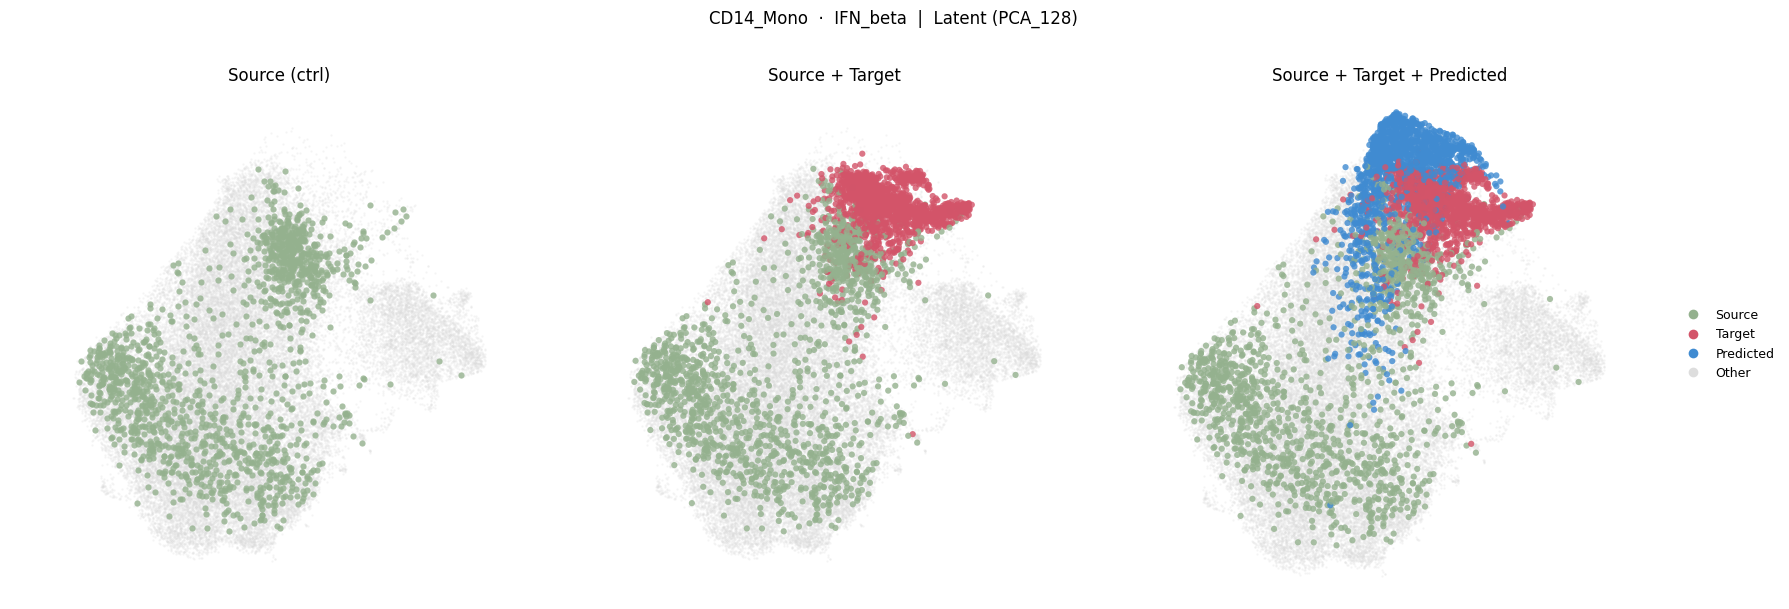


Computing CD14_Mono UMAP — Gene space (decoded)  (1 highlighted perts) ...
  UMAP input: 50,208 cells (focus kept full, others ≤200/group)
  Saved -> ../figs/fig4/umap_test_gene_CD14_Monoct_IFN_beta_3panel_PCA_128.svg


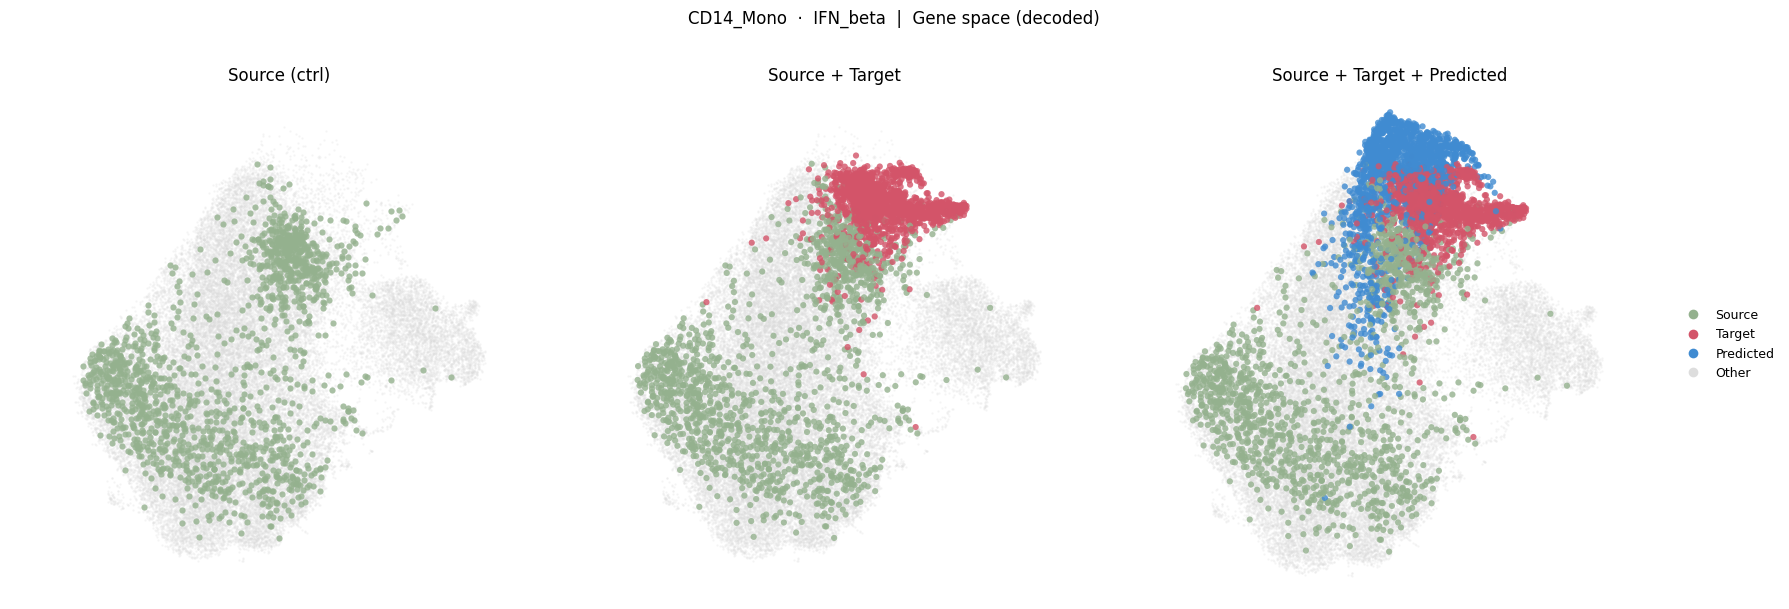

In [15]:
MODEL_NAME   = "PCA_128"

with open("../frozen/st_umaps_pca128.pkl", "rb") as f:
    res_bcell = pickle.load(f)
    f.close()

FOCUS_CT    = "CD14_Mono"
FOCUS_PERTS = ["IFN_beta"]
UMAP_MAX_PER_GROUP = 200

def make_umap_bcell(res, space, cell_type, focus_perts,
                    max_per_group=200, seed=42):
    """UMAP on a single cell-type. Subsample non-focus perts to max_per_group
    cells per (source, pert) to keep UMAP tractable; focus perts kept in full."""
    keys = {
        "emb":  ("ctrl_emb", "pert_emb", "pred_emb"),
        "gene": ("ctrl_gene", "pert_gene", "pred_gene"),
    }[space]
    rng    = np.random.default_rng(seed)
    ct_arr = np.array(res["cell_type"])
    pt_arr = np.array(res["pert_name"])

    parts, sources, perts_col = [], [], []
    for arr, src in zip([res[k] for k in keys], ["ctrl", "pert_true", "pred"]):
        base_idx = np.where(ct_arr == cell_type)[0]
        for pert in np.unique(pt_arr[base_idx]):
            idx = base_idx[pt_arr[base_idx] == pert]
            if pert not in focus_perts and len(idx) > max_per_group:
                idx = rng.choice(idx, max_per_group, replace=False)
            parts.append(arr[idx].astype(np.float32))
            sources.extend([src] * len(idx))
            perts_col.extend([pert] * len(idx))

    X       = np.concatenate(parts, axis=0)
    obs_df  = pd.DataFrame({"source": sources, "pert_name": perts_col})
    adata_u = ad.AnnData(X=X, obs=obs_df)
    adata_u.obs_names = [str(i) for i in range(len(adata_u))]
    n_pcs = min(50, adata_u.n_obs - 1, adata_u.n_vars - 1)
    sc.pp.pca(adata_u, n_comps=n_pcs)
    sc.pp.neighbors(adata_u, n_pcs=n_pcs)
    sc.tl.umap(adata_u)
    print(f"  UMAP input: {len(adata_u):,} cells "
          f"(focus kept full, others ≤{max_per_group}/group)")
    return adata_u

DOT_SIZE = 20
DOT_ALPHA = 0.8
SOURCE_PALETTE = {"ctrl": "#94B18E", "pert_true": "#D35469", "pred": "#408BD1"}

for space, label in [("emb", f"Latent ({MODEL_NAME})"), ("gene", "Gene space (decoded)")]:
    ct_mask   = np.array(res_bcell["cell_type"]) == FOCUS_CT
    available = [p for p in FOCUS_PERTS
                 if p in set(np.array(res_bcell["pert_name"])[ct_mask])]
    if not available:
        print(f"No {FOCUS_CT!r} data for {FOCUS_PERTS} — skipping {label}")
        continue

    print(f"\nComputing {FOCUS_CT} UMAP — {label}  ({len(available)} highlighted perts) ...")
    adata_u = make_umap_bcell(res_bcell, space, FOCUS_CT,
                              focus_perts=available,
                              max_per_group=UMAP_MAX_PER_GROUP)
    coords  = adata_u.obsm["X_umap"]

    for pert in available:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        bg = ~np.isin(adata_u.obs["pert_name"].values, [pert])
        fg_ctrl = ((adata_u.obs["source"] == "ctrl") & (adata_u.obs["pert_name"] == pert)).values
        fg_true = ((adata_u.obs["source"] == "pert_true") & (adata_u.obs["pert_name"] == pert)).values
        fg_pred = ((adata_u.obs["source"] == "pred") & (adata_u.obs["pert_name"] == pert)).values

        ax = axes[0]
        ax.scatter(coords[bg, 0], coords[bg, 1],
                   c="#dddddd", s=1, alpha=0.15, rasterized=True, zorder=1)
        ax.scatter(coords[fg_ctrl, 0], coords[fg_ctrl, 1],
                   c=SOURCE_PALETTE["ctrl"], s=DOT_SIZE, alpha=DOT_ALPHA,
                   rasterized=True, zorder=2, linewidths=0)
        ax.set_title(f"Source (ctrl)")

        ax = axes[1]
        ax.scatter(coords[bg, 0], coords[bg, 1],
                   c="#dddddd", s=1, alpha=0.15, rasterized=True, zorder=1)
        fg = fg_ctrl | fg_true
        fg_idx = np.where(fg)[0]
        np.random.default_rng(42).shuffle(fg_idx)
        fg_colors = [SOURCE_PALETTE[adata_u.obs.iloc[i]["source"]] for i in fg_idx]
        ax.scatter(coords[fg_idx, 0], coords[fg_idx, 1],
                   c=fg_colors, s=DOT_SIZE, alpha=DOT_ALPHA,
                   rasterized=True, zorder=2, linewidths=0)
        ax.set_title(f"Source + Target")

        ax = axes[2]
        ax.scatter(coords[bg, 0], coords[bg, 1],
                   c="#dddddd", s=1, alpha=0.15, rasterized=True, zorder=1)
        fg = fg_ctrl | fg_true | fg_pred
        fg_idx = np.where(fg)[0]
        np.random.default_rng(42).shuffle(fg_idx)
        fg_colors = [SOURCE_PALETTE[adata_u.obs.iloc[i]["source"]] for i in fg_idx]
        ax.scatter(coords[fg_idx, 0], coords[fg_idx, 1],
                   c=fg_colors, s=DOT_SIZE, alpha=DOT_ALPHA,
                   rasterized=True, zorder=2, linewidths=0)
        ax.set_title(f"Source + Target + Predicted")

        for ax in axes:
            ax.axis("equal")
            ax.set_xticks([]); ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)

        legend_handles = [
            Line2D([0],[0], marker="o", color="w", markerfacecolor=SOURCE_PALETTE["ctrl"],
                   markersize=7, markeredgewidth=0, label="Source"),
            Line2D([0],[0], marker="o", color="w", markerfacecolor=SOURCE_PALETTE["pert_true"],
                   markersize=7, markeredgewidth=0, label="Target"),
            Line2D([0],[0], marker="o", color="w", markerfacecolor=SOURCE_PALETTE["pred"],
                   markersize=7, markeredgewidth=0, label="Predicted"),
            Line2D([0],[0], marker="o", color="w", markerfacecolor="#dddddd",
                   markersize=7, markeredgewidth=0, label="Other"),
        ]
        axes[-1].legend(handles=legend_handles, fontsize=9, frameon=False,
                        loc="center left", bbox_to_anchor=(1.02, 0.5))

        fig.suptitle(f"{FOCUS_CT}  ·  {pert}  |  {label}", fontsize=12, y=1.01)
        plt.tight_layout()
        svg_path = os.path.join(SVG_DIR,
            f"umap_{EVAL_SPLIT}_{space}_{'_'.join(FOCUS_CT.split())}ct_{pert}_3panel_{MODEL_NAME}.svg")
        plt.savefig(svg_path, format="svg", bbox_inches="tight")
        print(f"  Saved -> {svg_path}")
        plt.show()


Computing CD14_Mono UMAP — Latent (AE_2048)  (1 highlighted perts) ...
  UMAP input: 50,208 cells (focus kept full, others ≤200/group)
  Saved -> ../figs/fig4/umap_test_emb_CD14_Monoct_IFN_beta_3panel_AE_2048.svg


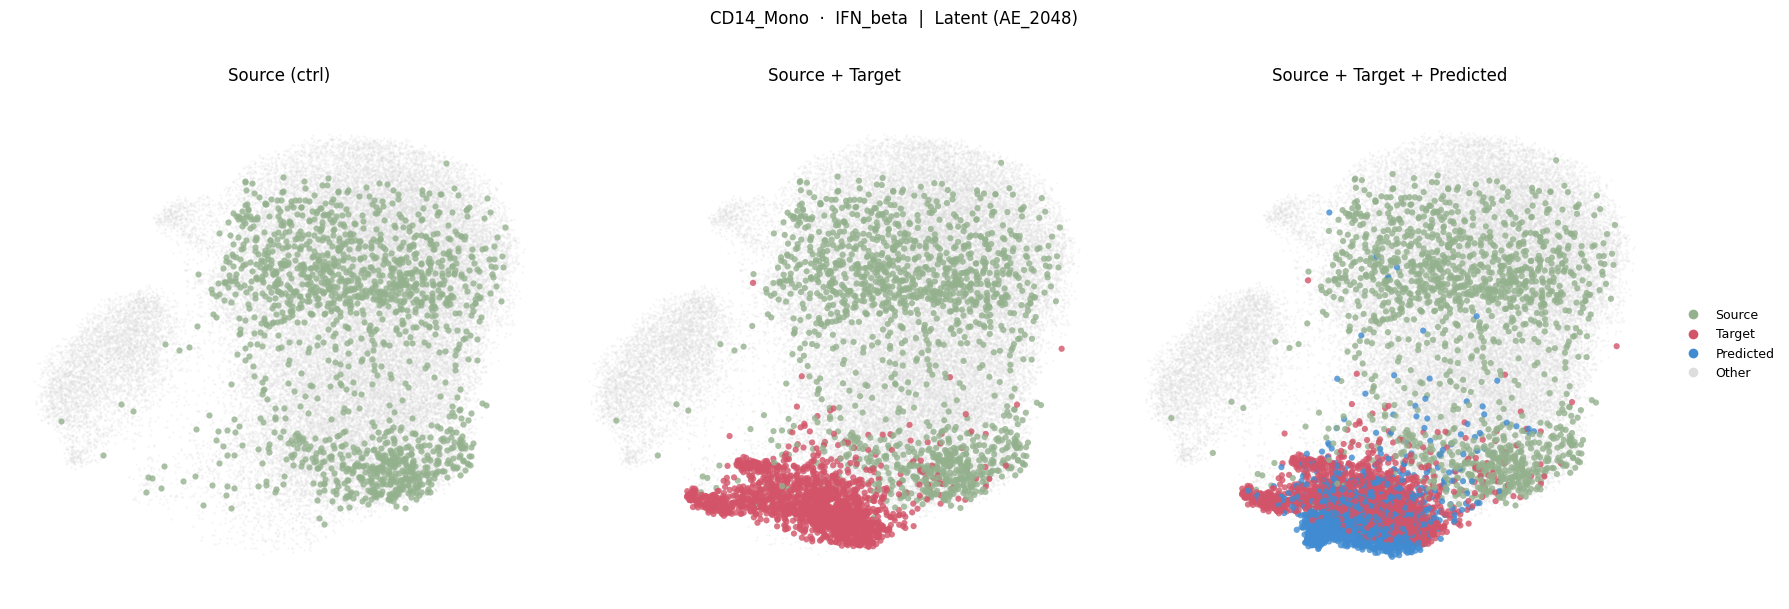


Computing CD14_Mono UMAP — Gene space (decoded)  (1 highlighted perts) ...
  UMAP input: 50,208 cells (focus kept full, others ≤200/group)
  Saved -> ../figs/fig4/umap_test_gene_CD14_Monoct_IFN_beta_3panel_AE_2048.svg


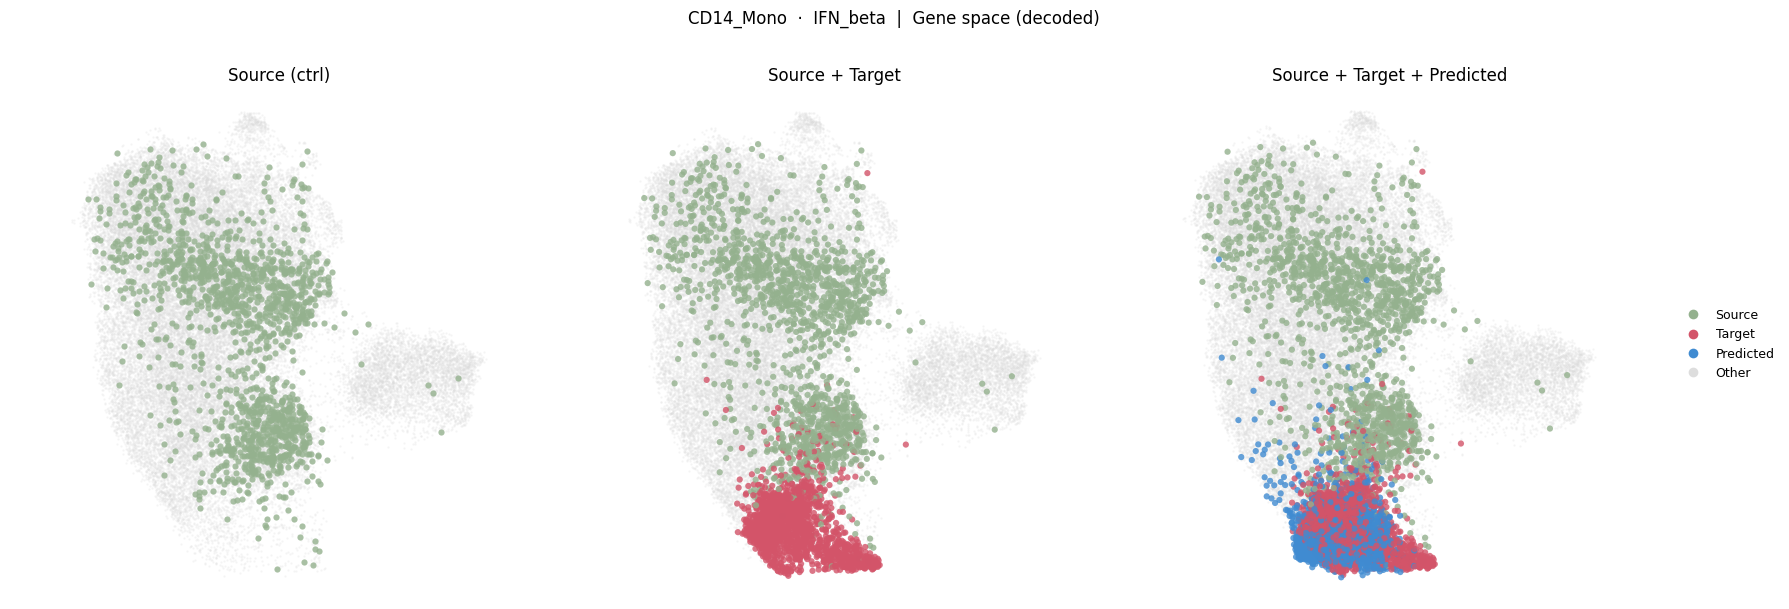

In [16]:
MODEL_NAME   = "AE_2048"

with open("../frozen/st_umaps_ae2048.pkl", "rb") as f:
    res_bcell = pickle.load(f)
    f.close()

FOCUS_CT    = "CD14_Mono"
FOCUS_PERTS = ["IFN_beta"]
UMAP_MAX_PER_GROUP = 200

def make_umap_bcell(res, space, cell_type, focus_perts,
                    max_per_group=200, seed=42):
    """UMAP on a single cell-type. Subsample non-focus perts to max_per_group
    cells per (source, pert) to keep UMAP tractable; focus perts kept in full."""
    keys = {
        "emb":  ("ctrl_emb", "pert_emb", "pred_emb"),
        "gene": ("ctrl_gene", "pert_gene", "pred_gene"),
    }[space]
    rng    = np.random.default_rng(seed)
    ct_arr = np.array(res["cell_type"])
    pt_arr = np.array(res["pert_name"])

    parts, sources, perts_col = [], [], []
    for arr, src in zip([res[k] for k in keys], ["ctrl", "pert_true", "pred"]):
        base_idx = np.where(ct_arr == cell_type)[0]
        for pert in np.unique(pt_arr[base_idx]):
            idx = base_idx[pt_arr[base_idx] == pert]
            if pert not in focus_perts and len(idx) > max_per_group:
                idx = rng.choice(idx, max_per_group, replace=False)
            parts.append(arr[idx].astype(np.float32))
            sources.extend([src] * len(idx))
            perts_col.extend([pert] * len(idx))

    X       = np.concatenate(parts, axis=0)
    obs_df  = pd.DataFrame({"source": sources, "pert_name": perts_col})
    adata_u = ad.AnnData(X=X, obs=obs_df)
    adata_u.obs_names = [str(i) for i in range(len(adata_u))]
    n_pcs = min(50, adata_u.n_obs - 1, adata_u.n_vars - 1)
    sc.pp.pca(adata_u, n_comps=n_pcs)
    sc.pp.neighbors(adata_u, n_pcs=n_pcs)
    sc.tl.umap(adata_u)
    print(f"  UMAP input: {len(adata_u):,} cells "
          f"(focus kept full, others ≤{max_per_group}/group)")
    return adata_u

DOT_SIZE = 20
DOT_ALPHA = 0.8
SOURCE_PALETTE = {"ctrl": "#94B18E", "pert_true": "#D35469", "pred": "#408BD1"}

for space, label in [("emb", f"Latent ({MODEL_NAME})"), ("gene", "Gene space (decoded)")]:
    ct_mask   = np.array(res_bcell["cell_type"]) == FOCUS_CT
    available = [p for p in FOCUS_PERTS
                 if p in set(np.array(res_bcell["pert_name"])[ct_mask])]
    if not available:
        print(f"No {FOCUS_CT!r} data for {FOCUS_PERTS} — skipping {label}")
        continue

    print(f"\nComputing {FOCUS_CT} UMAP — {label}  ({len(available)} highlighted perts) ...")
    adata_u = make_umap_bcell(res_bcell, space, FOCUS_CT,
                              focus_perts=available,
                              max_per_group=UMAP_MAX_PER_GROUP)
    coords  = adata_u.obsm["X_umap"]

    for pert in available:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        bg = ~np.isin(adata_u.obs["pert_name"].values, [pert])
        fg_ctrl = ((adata_u.obs["source"] == "ctrl") & (adata_u.obs["pert_name"] == pert)).values
        fg_true = ((adata_u.obs["source"] == "pert_true") & (adata_u.obs["pert_name"] == pert)).values
        fg_pred = ((adata_u.obs["source"] == "pred") & (adata_u.obs["pert_name"] == pert)).values

        ax = axes[0]
        ax.scatter(coords[bg, 0], coords[bg, 1],
                   c="#dddddd", s=1, alpha=0.15, rasterized=True, zorder=1)
        ax.scatter(coords[fg_ctrl, 0], coords[fg_ctrl, 1],
                   c=SOURCE_PALETTE["ctrl"], s=DOT_SIZE, alpha=DOT_ALPHA,
                   rasterized=True, zorder=2, linewidths=0)
        ax.set_title(f"Source (ctrl)")

        ax = axes[1]
        ax.scatter(coords[bg, 0], coords[bg, 1],
                   c="#dddddd", s=1, alpha=0.15, rasterized=True, zorder=1)
        fg = fg_ctrl | fg_true
        fg_idx = np.where(fg)[0]
        np.random.default_rng(42).shuffle(fg_idx)
        fg_colors = [SOURCE_PALETTE[adata_u.obs.iloc[i]["source"]] for i in fg_idx]
        ax.scatter(coords[fg_idx, 0], coords[fg_idx, 1],
                   c=fg_colors, s=DOT_SIZE, alpha=DOT_ALPHA,
                   rasterized=True, zorder=2, linewidths=0)
        ax.set_title(f"Source + Target")

        ax = axes[2]
        ax.scatter(coords[bg, 0], coords[bg, 1],
                   c="#dddddd", s=1, alpha=0.15, rasterized=True, zorder=1)
        fg = fg_ctrl | fg_true | fg_pred
        fg_idx = np.where(fg)[0]
        np.random.default_rng(42).shuffle(fg_idx)
        fg_colors = [SOURCE_PALETTE[adata_u.obs.iloc[i]["source"]] for i in fg_idx]
        ax.scatter(coords[fg_idx, 0], coords[fg_idx, 1],
                   c=fg_colors, s=DOT_SIZE, alpha=DOT_ALPHA,
                   rasterized=True, zorder=2, linewidths=0)
        ax.set_title(f"Source + Target + Predicted")

        for ax in axes:
            ax.axis("equal")
            ax.set_xticks([]); ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)

        legend_handles = [
            Line2D([0],[0], marker="o", color="w", markerfacecolor=SOURCE_PALETTE["ctrl"],
                   markersize=7, markeredgewidth=0, label="Source"),
            Line2D([0],[0], marker="o", color="w", markerfacecolor=SOURCE_PALETTE["pert_true"],
                   markersize=7, markeredgewidth=0, label="Target"),
            Line2D([0],[0], marker="o", color="w", markerfacecolor=SOURCE_PALETTE["pred"],
                   markersize=7, markeredgewidth=0, label="Predicted"),
            Line2D([0],[0], marker="o", color="w", markerfacecolor="#dddddd",
                   markersize=7, markeredgewidth=0, label="Other"),
        ]
        axes[-1].legend(handles=legend_handles, fontsize=9, frameon=False,
                        loc="center left", bbox_to_anchor=(1.02, 0.5))

        fig.suptitle(f"{FOCUS_CT}  ·  {pert}  |  {label}", fontsize=12, y=1.01)
        plt.tight_layout()
        svg_path = os.path.join(SVG_DIR,
            f"umap_{EVAL_SPLIT}_{space}_{'_'.join(FOCUS_CT.split())}ct_{pert}_3panel_{MODEL_NAME}.svg")
        plt.savefig(svg_path, format="svg", bbox_inches="tight")
        print(f"  Saved -> {svg_path}")
        plt.show()